# Evaluate benchmark

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
from tqdm import tqdm
from pathlib import Path

from scatlastb_utils.io import read_anndata
from scatlastb_utils.utils import dask_compute

sc.set_figure_params(frameon=False, dpi=80, fontsize=12, dpi_save=300)
plt.rcParams["svg.fonttype"] = "none"

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from misc import clean_prefixes

In [4]:
figure_dir = Path('figures/figure3')
figure_dir.mkdir(exist_ok=True, parents=True)

## Read data

In [5]:
def read_data(lineage):
    adata = read_anndata(
        f'data/pipeline/HRCA/majority_voting/dataset~{lineage}/file_id~collect:{lineage}.zarr',
        obs='obs',
        obsm='obsm',
        uns='uns',
        dask=True,
        backed=True,
        # verbose=False,
        dask_slots=['X', 'layers', 'obsp'],
        select_keys='metrics--.*',
    )
    clean_prefixes(adata, 'metrics:')
    
    # set majority_consensus labels
    adata.obs['majority_consensus'] = pd.Categorical(
        adata.obs['majority_consensus'],
        categories=adata.obs['ann_finest_level'].cat.categories
    )
    adata.obs['majority_consensus_disagreement'] = 1 - adata.obs['majority_consensus_agreement']
    
    for col in adata.obs.select_dtypes(include=["object", "category"]):
        adata.obs[col] = adata.obs[col].where(
            ~adata.obs[col].astype(str).str.contains("unknown", na=False),
            np.nan
        )
    return adata

In [6]:
# tqdm._instances.clear()
adatas = {
    lineage: read_data(lineage)
    for lineage in tqdm(['AC', 'BC', 'RGC'])
}

  0%|          | 0/3 [00:00<?, ?it/s]

dask: True, backed: True
chunks: (200000, -1)
Read slot "obs", store as "obs"...
Read slot "obsm", store as "obsm"...
select only slots that match metrics--.*
Read slot "uns", store as "uns"...
select only slots that match metrics--.*



Read uns slots as_dask=False: 100%|██████████| 32/32 [00:01<00:00, 18.30it/s]

shape: (571579, 0)



 33%|███▎      | 1/3 [00:40<01:20, 40.32s/it]

...

 67%|██████▋   | 2/3 [01:26<00:43, 43.62s/it]

dask: True, backed: True
chunks: (200000, -1)
Read slot "obs", store as "obs"...
Read slot "obsm", store as "obsm"...
select only slots that match metrics--.*
Read slot "uns", store as "uns"...
select only slots that match metrics--.*



Read uns slots as_dask=False: 100%|██████████| 32/32 [00:01<00:00, 20.00it/s]


shape: (399605, 0)


100%|██████████| 3/3 [01:53<00:00, 37.69s/it]


In [7]:
def get_metrics_df(adata):
    df = pd.concat([adata.uns[key] for key in adata.uns if 'metrics--' in key])
    
    file_id_parsed = df['file_id'].str.split("--") \
        .apply(lambda x: dict(i.split("=") for i in x if "=" in i)) \
        .apply(pd.Series)
    df[file_id_parsed.columns] = file_id_parsed
    
    # nicer metric type names
    df['metric_type'] = df['metric_type'].map(
        {
            'bio_conservation': 'Bio conservation',
            'batch_correction': 'Batch correction'
        }
    )
    
    # dedicated column parsing
    df['n_hvgs'] = df['n_hvgs'].astype(int)
    df['hvg_batch'] = df['batch']
    df['hvg_strategy'] = df.apply(lambda r: f"n={r['n_hvgs']}_batch={r['hvg_batch']}", axis=1)
    df['lineage'] = df['dataset']
    df['method'] = df['file_name']
    df['resolution'] = df['strategy']
    
    df["score_scaled"] = (
        df.groupby(["metric"])["score"]
          .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
    )
    return df

In [8]:
metrics_df = pd.concat(
    [get_metrics_df(adata) for adata in adatas.values()]
).reset_index(drop=True) 

In [9]:
metrics_df.to_csv('data/output/HRCA/metrics_df.tsv', sep='\t', index=False)

In [10]:
metrics_df = pd.read_table('data/output/HRCA/metrics_df.tsv')
metrics_df['hvg_batch'] = metrics_df['hvg_batch'].fillna('None') 

## Batch/bio Tradeoffs

In [11]:
summary = (
    metrics_df.groupby([
        "method",
        "resolution",
        "hvg_strategy",
        "n_hvgs",
        "hvg_batch",
        "lineage",
        "metric_type"
    ])["score_scaled"]
      .mean()
      .unstack("metric_type")
      .reset_index()
)

# summarise scores
summary['Overall score'] = (0.4 * summary['Batch correction'] + 0.6 * summary['Bio conservation'])
summary.sort_values('Overall score', ascending=False, inplace=True)

# mark best performers
summary['is_max_in_lineage'] = summary['Overall score'] == summary.groupby('lineage')['Overall score'].transform('max')

# n_cells per lineage
summary['n_cells'] = summary['lineage'].map(lambda l: adatas[l].n_obs if l in adatas else None)
summary['lineage_n_cells'] = summary['lineage'] + ', n=' + summary['n_cells'].astype(str)

summary.dtypes

metric_type
method                object
resolution            object
hvg_strategy          object
n_hvgs                 int64
hvg_batch             object
lineage               object
Batch correction     float64
Bio conservation     float64
Overall score        float64
is_max_in_lineage       bool
n_cells                int64
lineage_n_cells       object
dtype: object

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _handle_color(h):
    """Pull a usable color from a legend handle, whatever its type."""
    for getter in ("get_color", "get_markerfacecolor", "get_facecolor"):
        if hasattr(h, getter):
            try:
                c = getattr(h, getter)()
                if hasattr(c, "__len__") and len(c) and hasattr(c[0], "__len__"):
                    c = c[0]
                return c
            except Exception:
                pass
    return "grey"


def _add_corr_legend(ax, entries, hue_colors, corr_method, loc):
    """Correlation legend on one axis: colored dots when hue_colors given,
    else text-only."""
    if hue_colors is not None:
        handles = [
            Line2D(
                [0], [0], marker="o", ls="",
                mfc=hue_colors.get(k, "grey"), mec="none",
                label=f"{k}: r={r:.2f}"
            ) for k, r in entries
        ]
        leg_kws = dict(handletextpad=0.3)
    else:
        handles = [
            Line2D([0], [0], marker="", ls="", label=f"{k}: r={r:.2f}")
            for k, r in entries
        ]
        leg_kws = dict(handlelength=0, handletextpad=0)
    ax.legend(
        handles=handles,
        title=f"{corr_method.capitalize()} correlation",
        loc=loc,
        title_fontsize=10,
        fontsize=9,
        framealpha=0.7,
        **leg_kws
    )


def _fold_into_hue_legend(g, df, x, y, cg, corr_method):
    """Append r values to the existing hue legend labels (single-axis case)."""
    corr_map = {
        str(k): s[x].corr(s[y], method=corr_method)
        for k, s in df.groupby(cg) if len(s) > 1
    }
    for text in g._legend.texts:
        label = text.get_text()
        r = corr_map.get(label)
        if r is None:  # numeric hue: legend text may be formatted differently
            try:
                r = next(v for k, v in corr_map.items() if float(k) == float(label))
            except (ValueError, StopIteration):
                r = None
        if r is not None:
            text.set_text(f"{label}\nr={r:.2f}")


def plot_tradeoff(
    df, x, y,
    hue=None, size=None, style=None,
    xlim=(0, 1), ylim=(0, 1),
    highlight_query=None, circle_size=400,
    return_plot=False,
    annotate_corr=True, corr_method="pearson", corr_group=None,
    corr_loc="upper left",
    lm_fit=False, save_path=None,
    **kwargs
):
    common = dict(data=df, x=x, y=y, hue=hue, aspect=1)
    if hue is not None:
        common["palette"] = "turbo"
    if lm_fit:
        defaults = dict(ci=None, legend=True,
                        scatter_kws={"alpha": 0.6}, line_kws={"linewidth": 2})
        g = sns.lmplot(**(common | defaults | kwargs))
    else:
        defaults = dict(kind="scatter", size=size, style=style,
                        sizes=(50, 200), legend="full")
        g = sns.relplot(**(common | defaults | kwargs))

    g.set(xlim=xlim, ylim=ylim)
    for ax in g.axes.flatten():
        ax.set_box_aspect(1)

    # ---- correlation legend ----
    if annotate_corr:
        cg = corr_group or hue
        color_by_hue = cg is not None and cg == hue

        if color_by_hue and not g.axes_dict and g._legend:
            # single axis + grouped by hue -> fold r into the hue legend
            _fold_into_hue_legend(g, df, x, y, cg, corr_method)
        else:
            hue_colors = None
            if color_by_hue and g._legend:
                hue_colors = {t.get_text(): _handle_color(h)
                              for t, h in zip(g._legend.texts,
                                              g._legend.legend_handles)}

            row_var = getattr(g, "_row_var", None)
            col_var = getattr(g, "_col_var", None)

            def facet_subset(key):
                if row_var and col_var:
                    r, c = key
                    return df[(df[row_var] == r) & (df[col_var] == c)]
                if col_var:
                    return df[df[col_var] == key]
                if row_var:
                    return df[df[row_var] == key]
                return df

            items = g.axes_dict.items() if g.axes_dict else [(None, g.ax)]
            for key, ax in items:
                sub = facet_subset(key)
                grouped = sub.groupby(cg) if cg else [("overall", sub)]
                entries = [(str(k), s[x].corr(s[y], method=corr_method))
                           for k, s in grouped if len(s) > 1]
                if entries:
                    _add_corr_legend(ax, entries, hue_colors, corr_method, corr_loc)

    # ---- highlight ----
    if highlight_query:
        highlight_df = df.query(highlight_query)
        for ax in g.axes.flatten():
            if not ax.collections:
                continue
            offsets = ax.collections[0].get_offsets()
            cx, cy = offsets[:, 0], offsets[:, 1]
            hits = highlight_df[highlight_df[x].isin(cx) & highlight_df[y].isin(cy)]
            if not hits.empty:
                ax.scatter(hits[x], hits[y], s=circle_size, facecolors="none",
                           edgecolors="red", linewidth=2, zorder=10)

    if save_path:
        g.savefig(save_path, format="svg", bbox_inches="tight")

    plt.show()

    if return_plot:
        return g

### Fig 3D

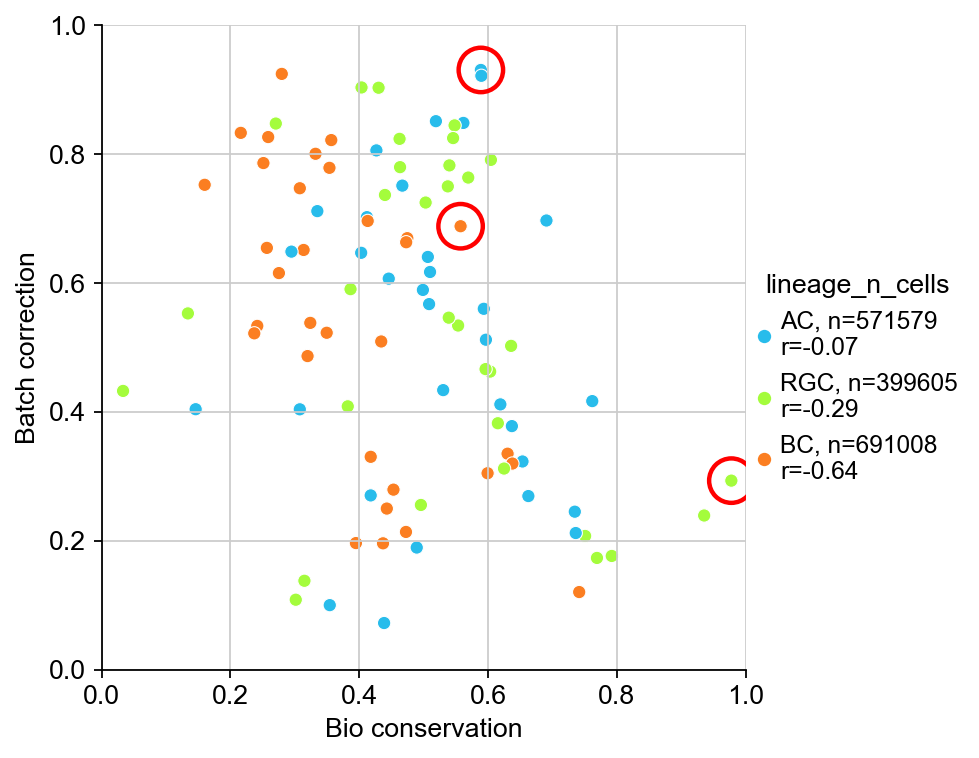

In [13]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='lineage_n_cells',
    # corr_group='lineage',
    lm_fit=False,
    highlight_query='is_max_in_lineage',
    save_path=figure_dir / "tradeoff_scatter_all_hue=lineage.svg",
)

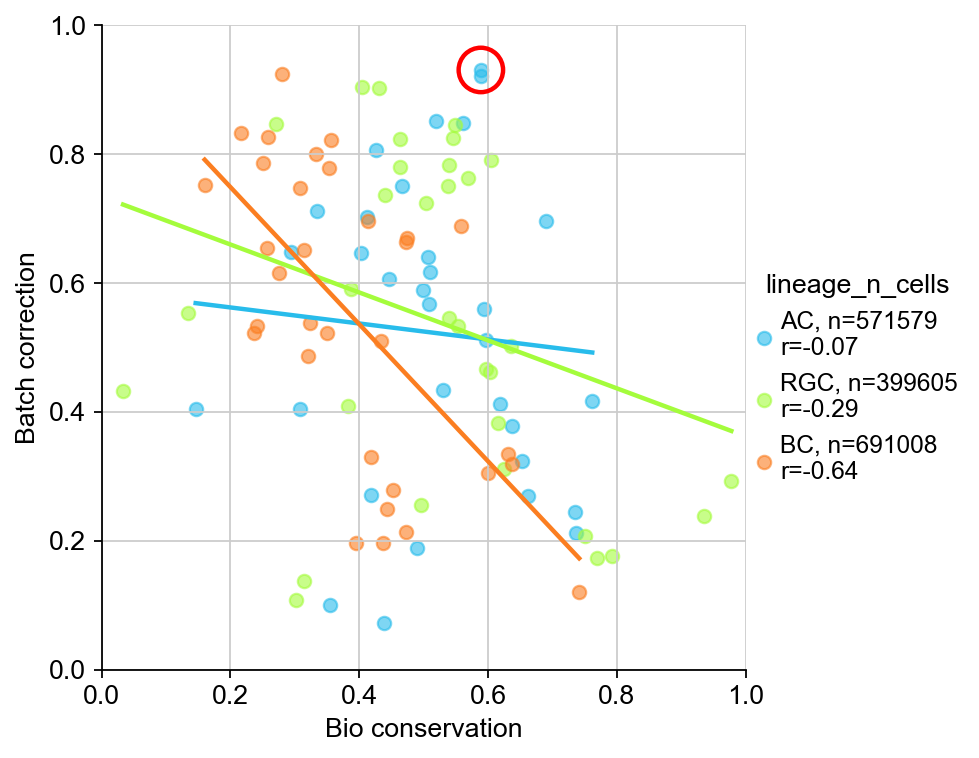

In [14]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='lineage_n_cells',
    lm_fit=True,
    highlight_query='is_max_in_lineage',
)

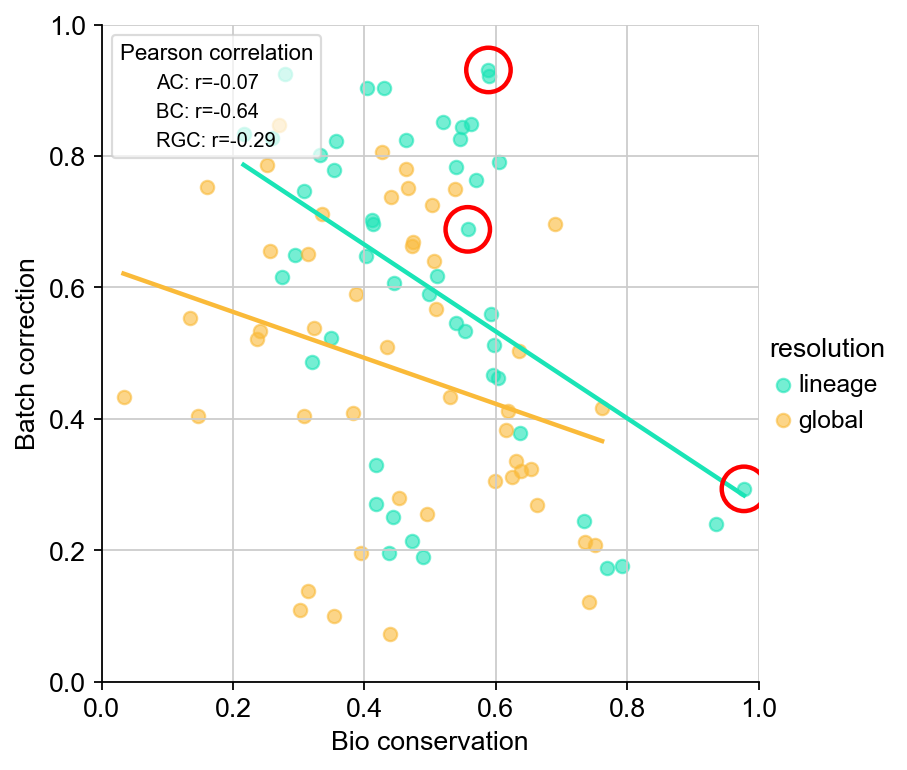

In [15]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='resolution',
    corr_group='lineage',
    lm_fit=True,
    highlight_query='is_max_in_lineage',
    save_path=figure_dir / "tradeoff_scatter_all_hue=resolution.svg",
)

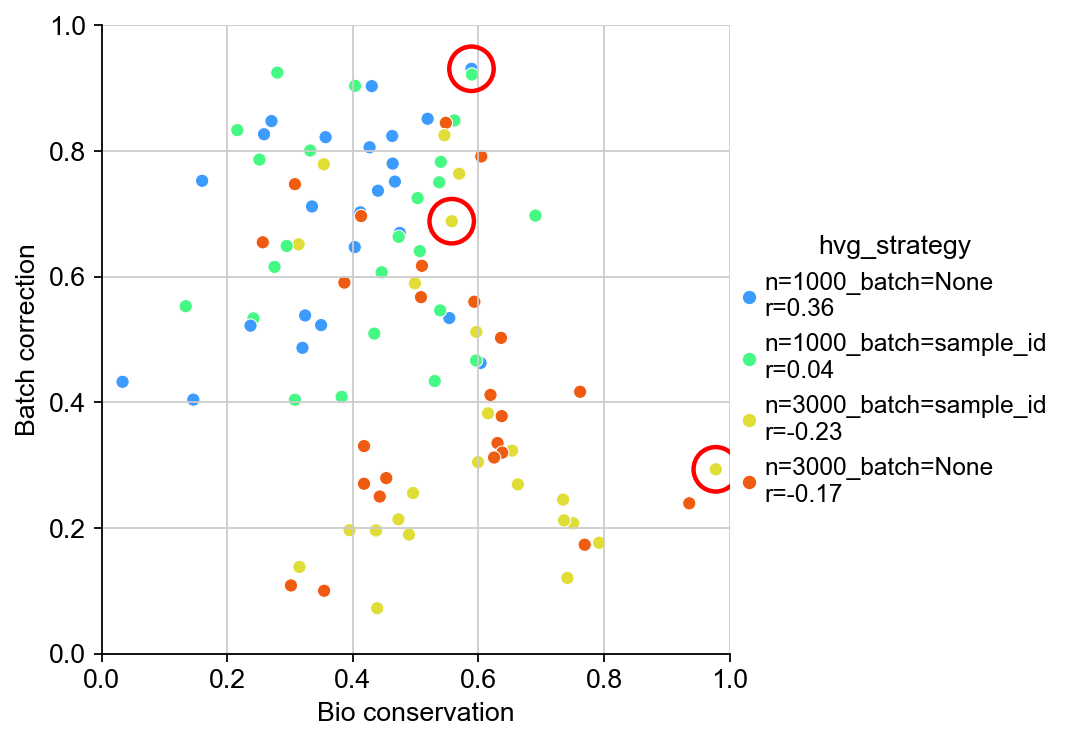

In [16]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='hvg_strategy',
    highlight_query='is_max_in_lineage',
)

### Fig 3E

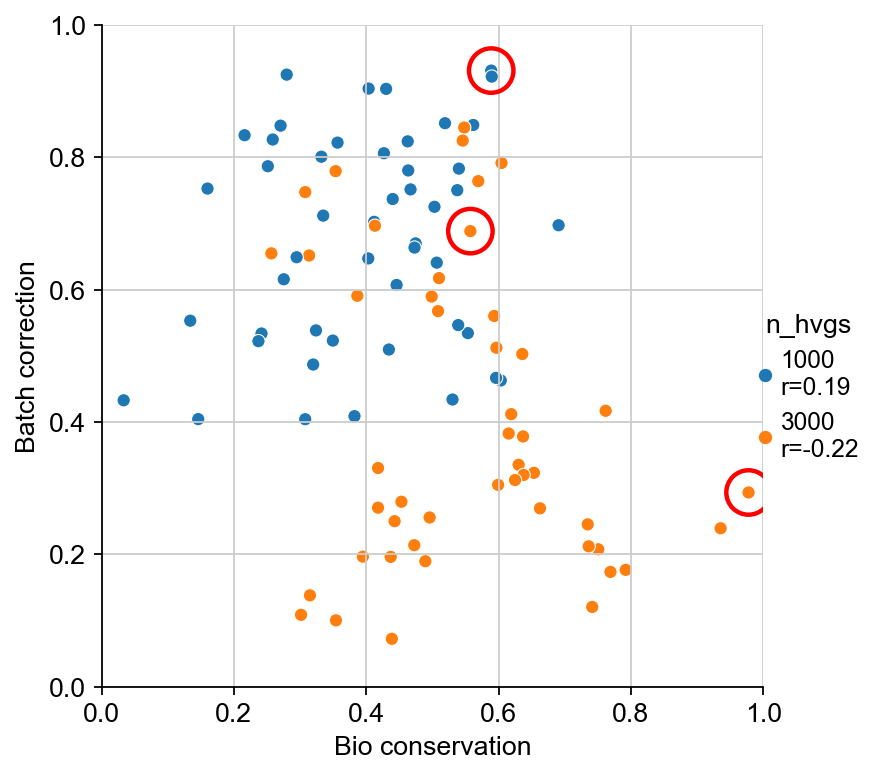

In [17]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='n_hvgs',
    palette='tab10',
    highlight_query='is_max_in_lineage',
    save_path=figure_dir / "tradeoff_scatter_all_hue=n_hvgs.svg",
)

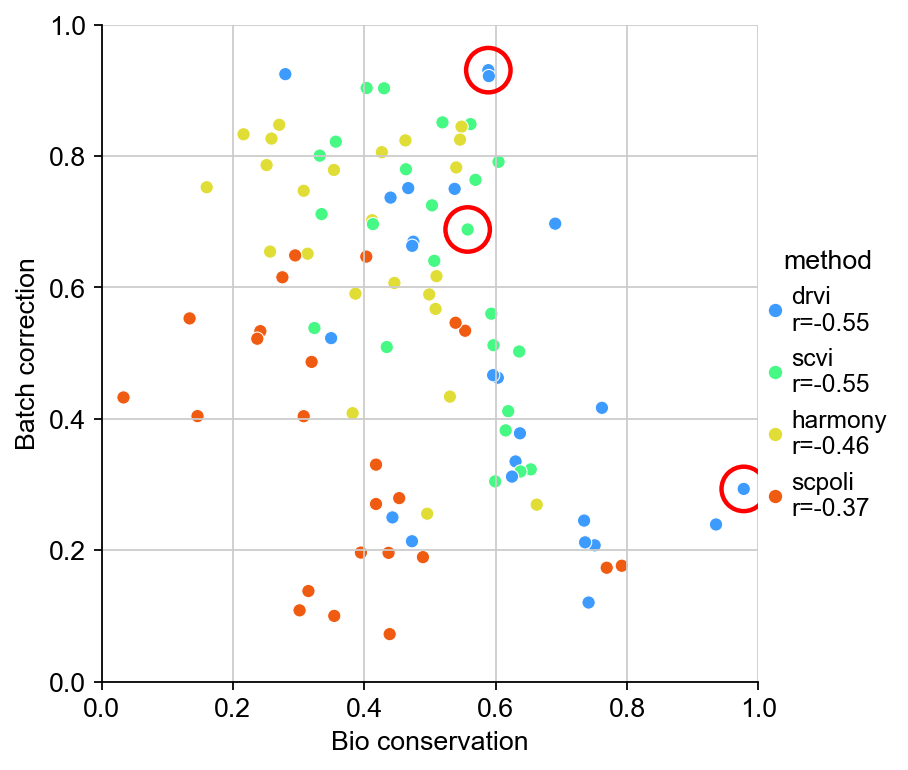

In [18]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='method',
    highlight_query='is_max_in_lineage',
)

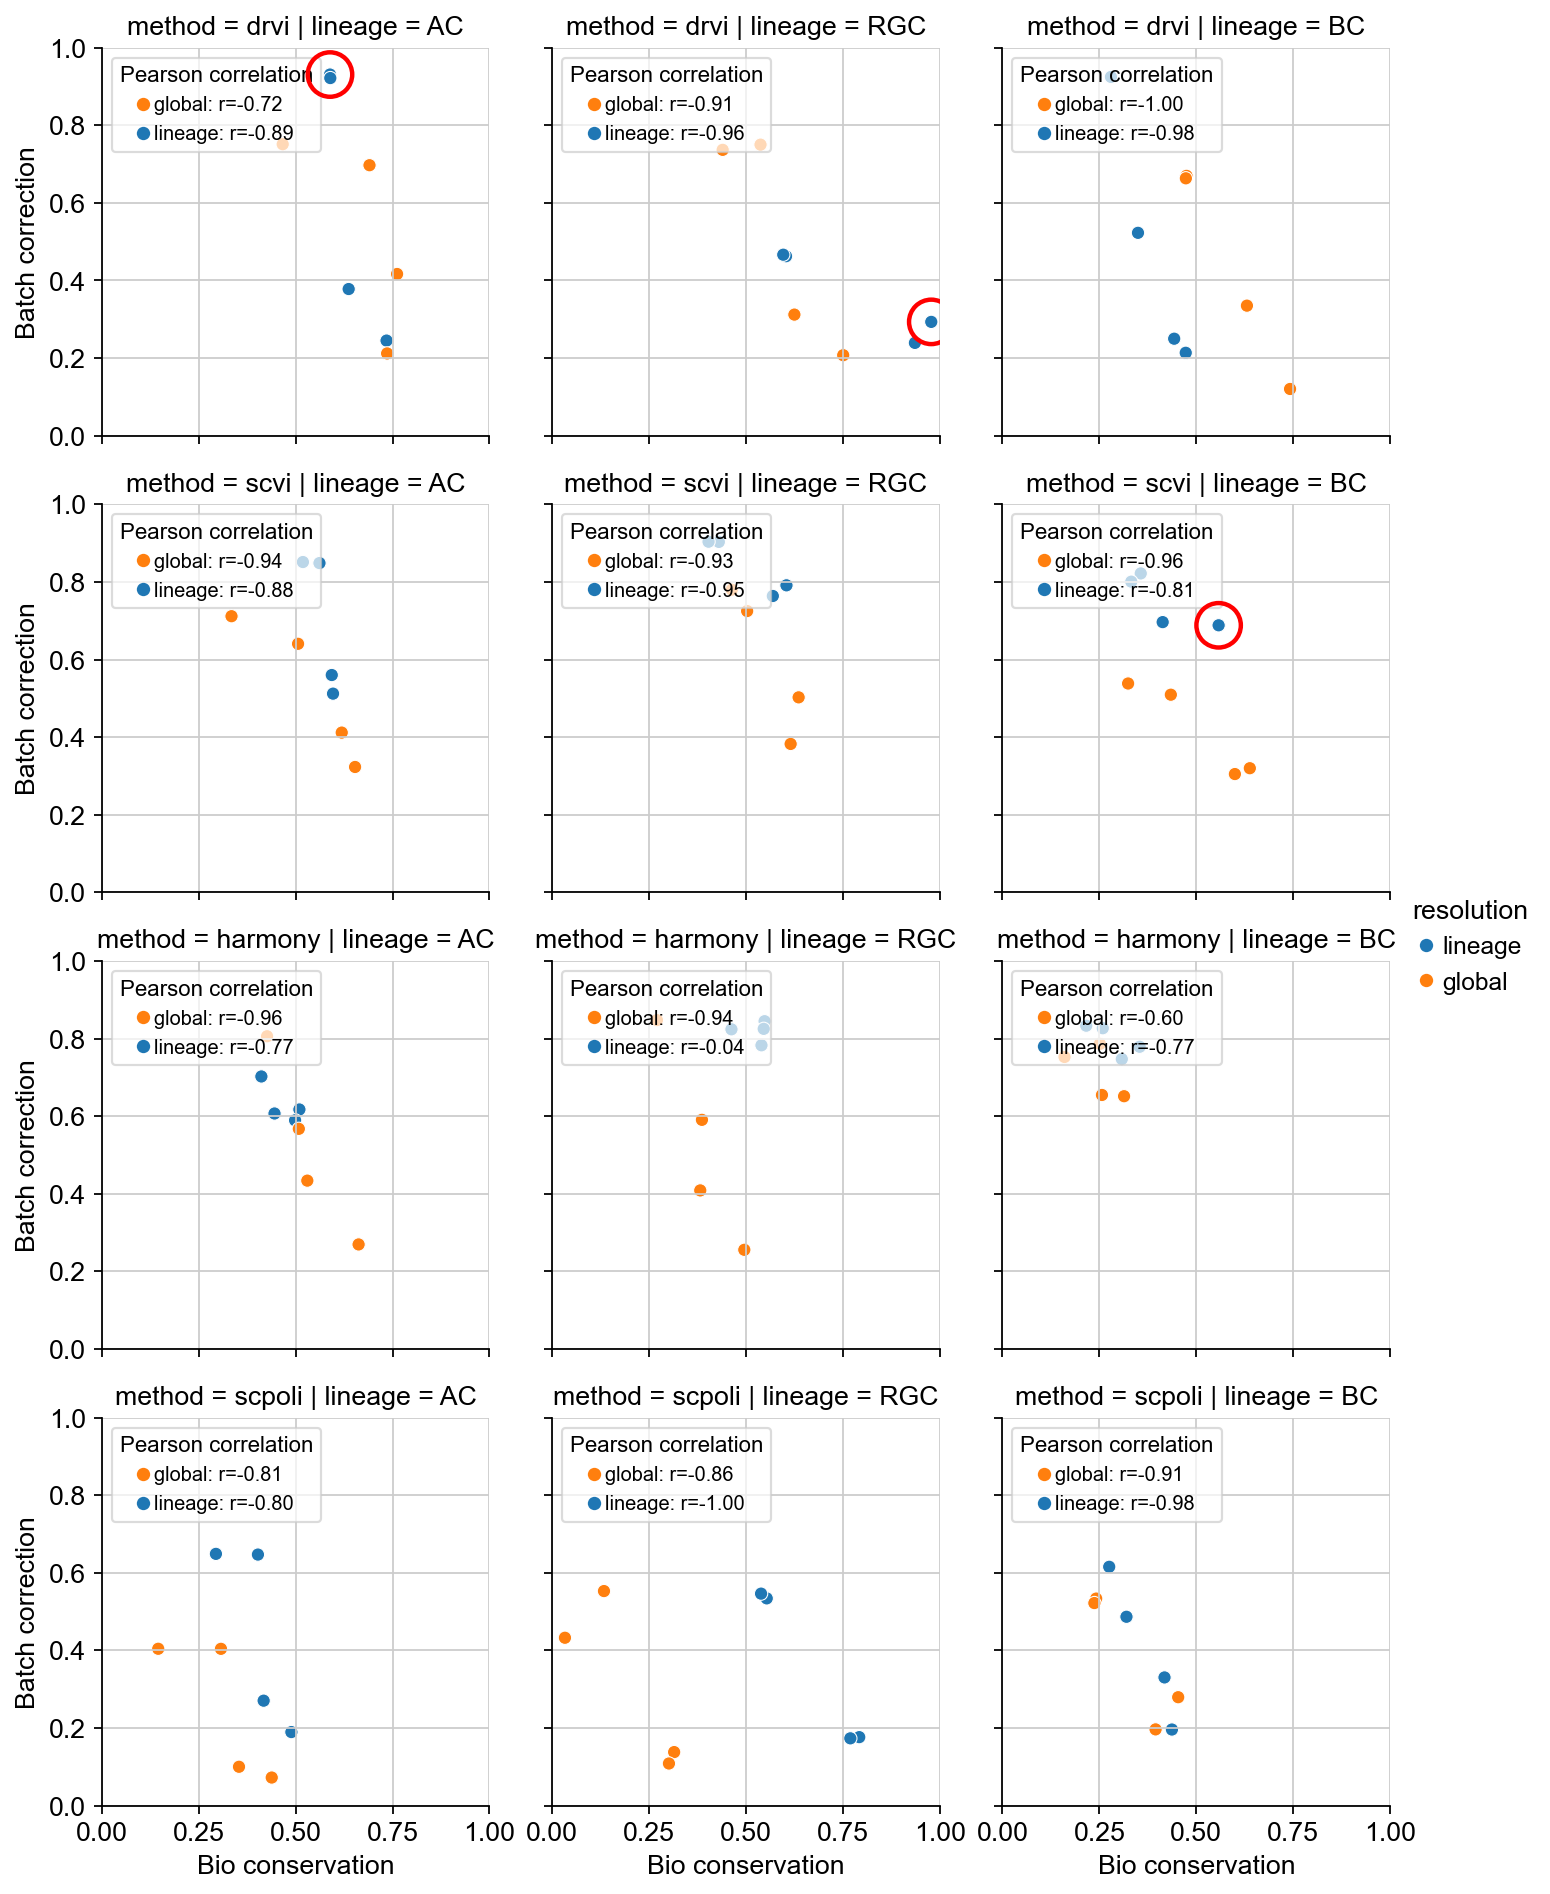

In [19]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='resolution',
    row='method',
    col='lineage',
    height=3,
    # s=50,
    palette='tab10',
    highlight_query='is_max_in_lineage',
)

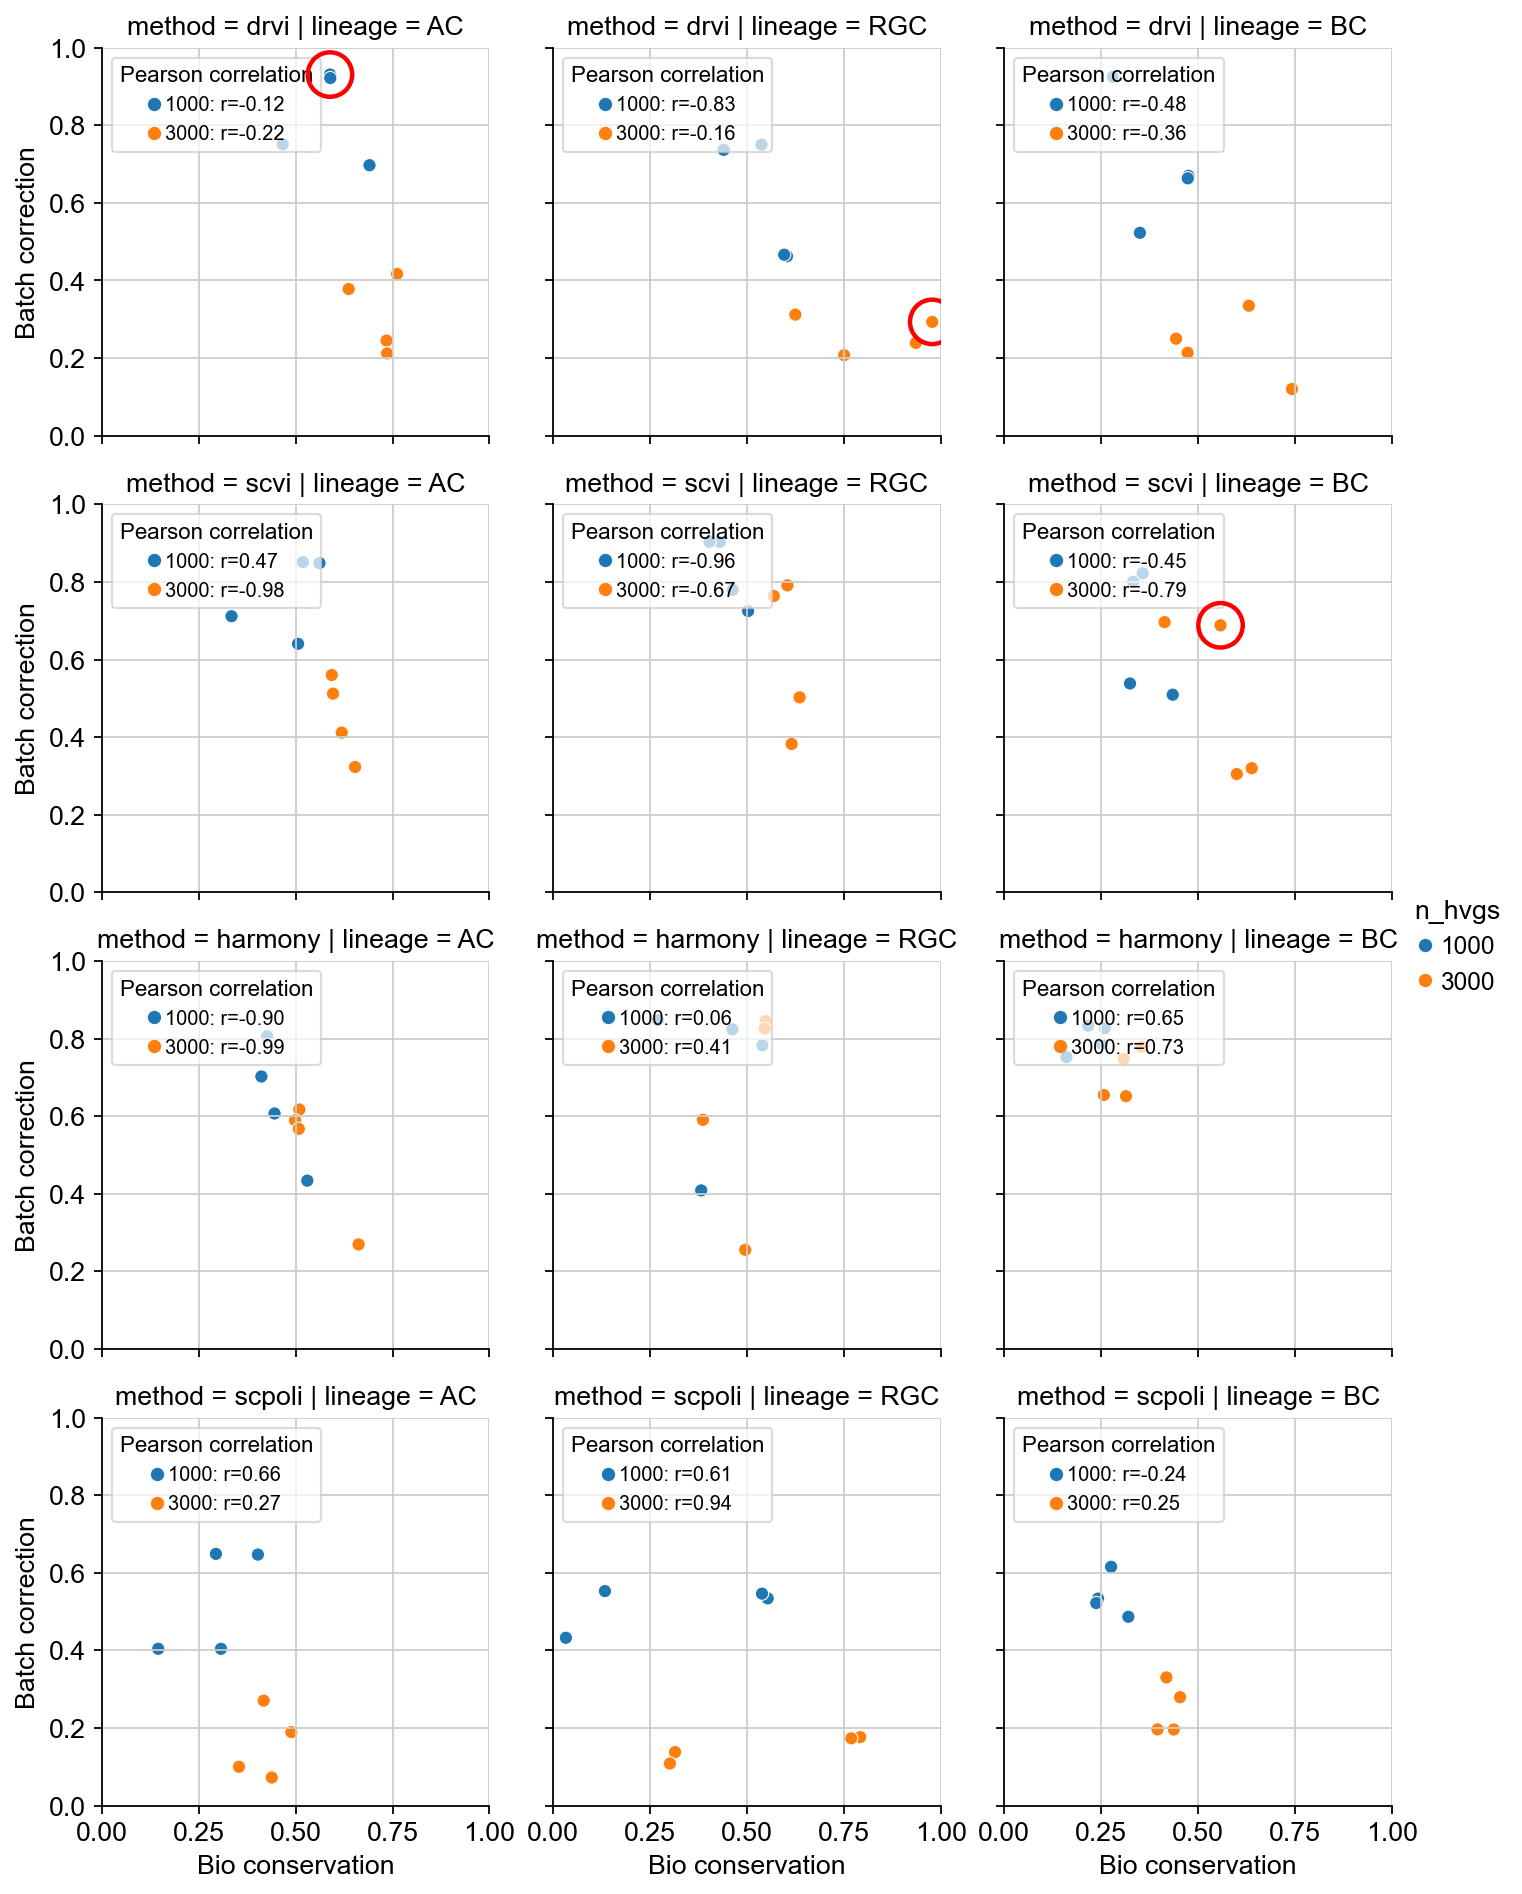

In [20]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    row='method',
    col='lineage',
    hue='n_hvgs',
    height=3,
    # s=50,
    palette='tab10',
    highlight_query='is_max_in_lineage',
)

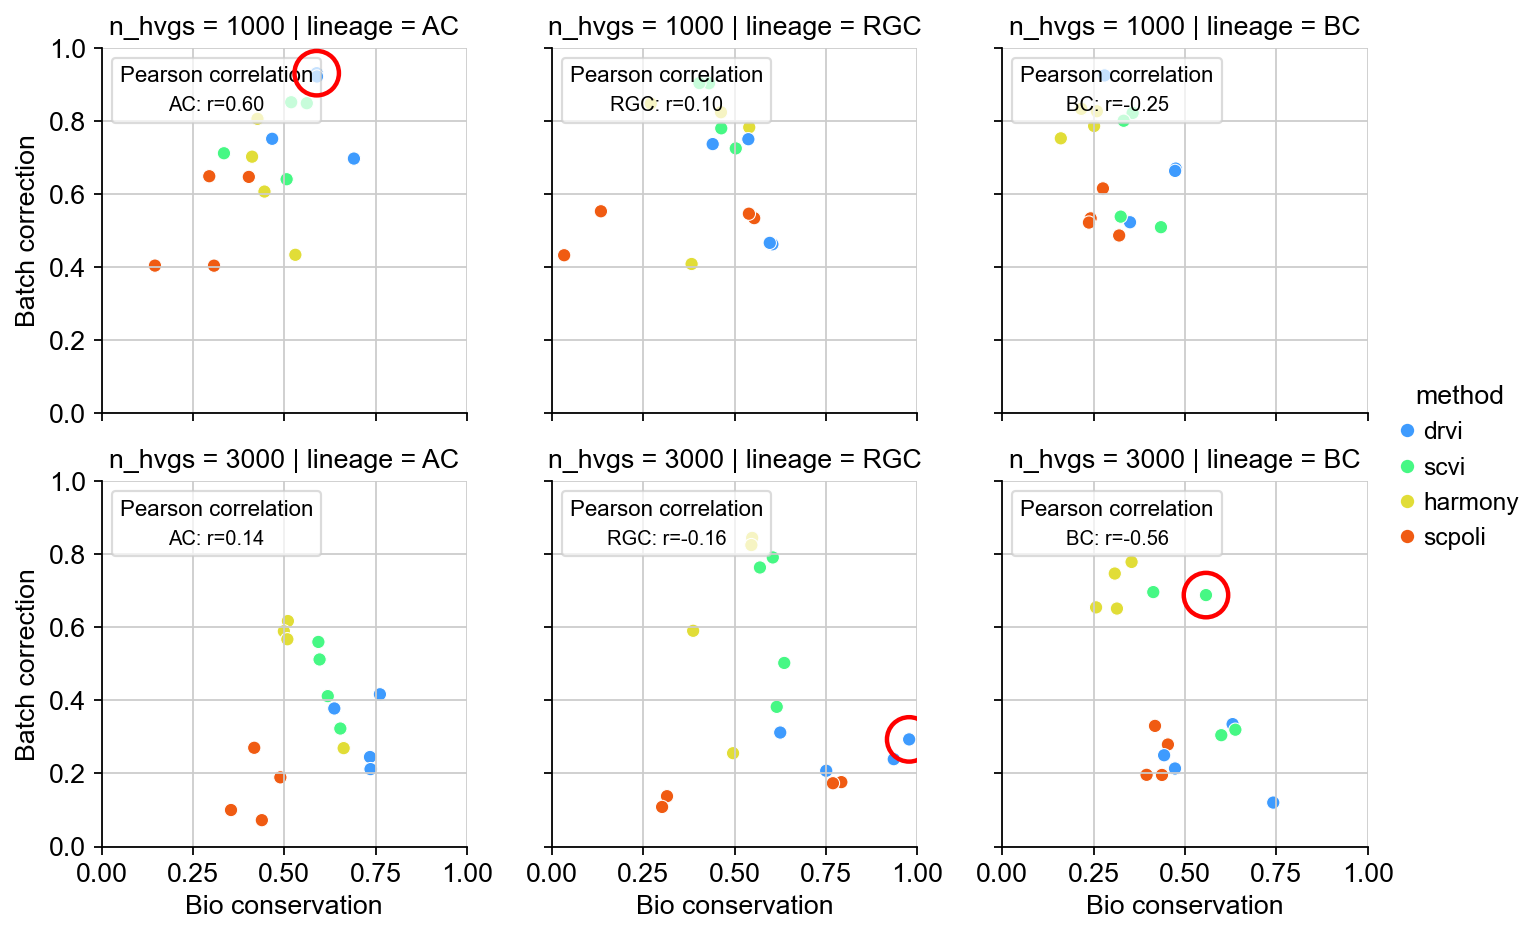

In [21]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='method',
    col='lineage',
    row='n_hvgs',
    height=3,
    corr_group='lineage',
    # s=60,
    highlight_query='is_max_in_lineage',
)

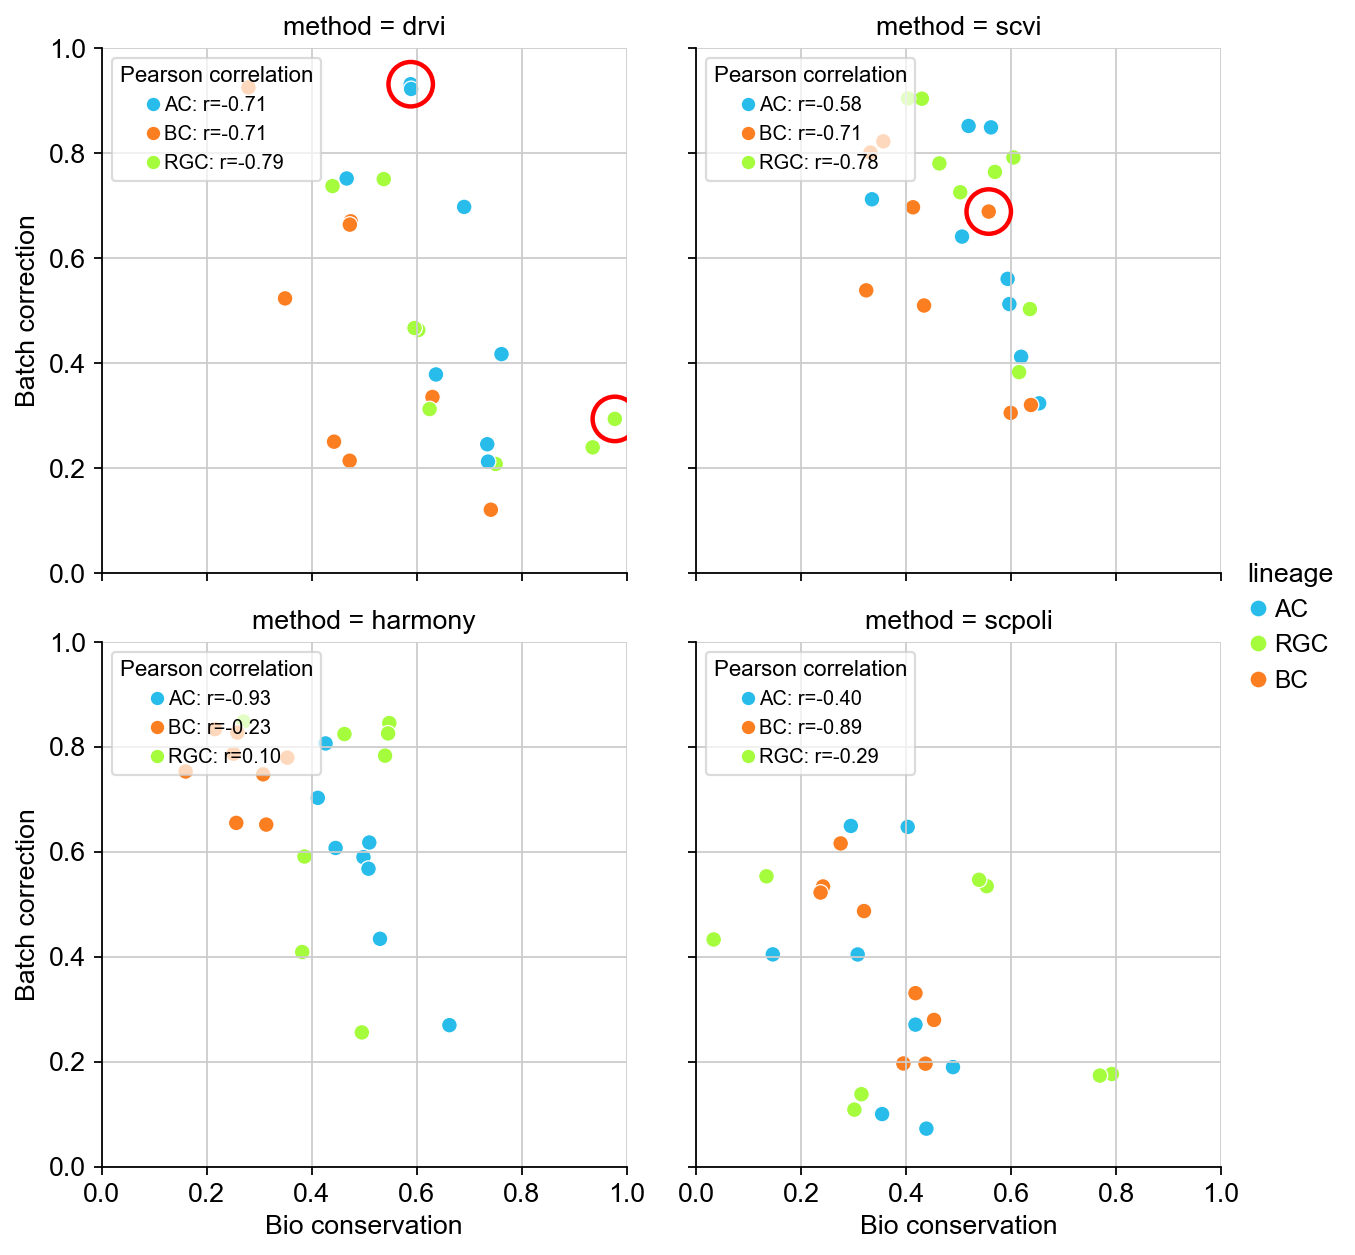

In [22]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='lineage',
    col='method',
    col_wrap=2,
    height=4,
    s=50,
    highlight_query='is_max_in_lineage',
)

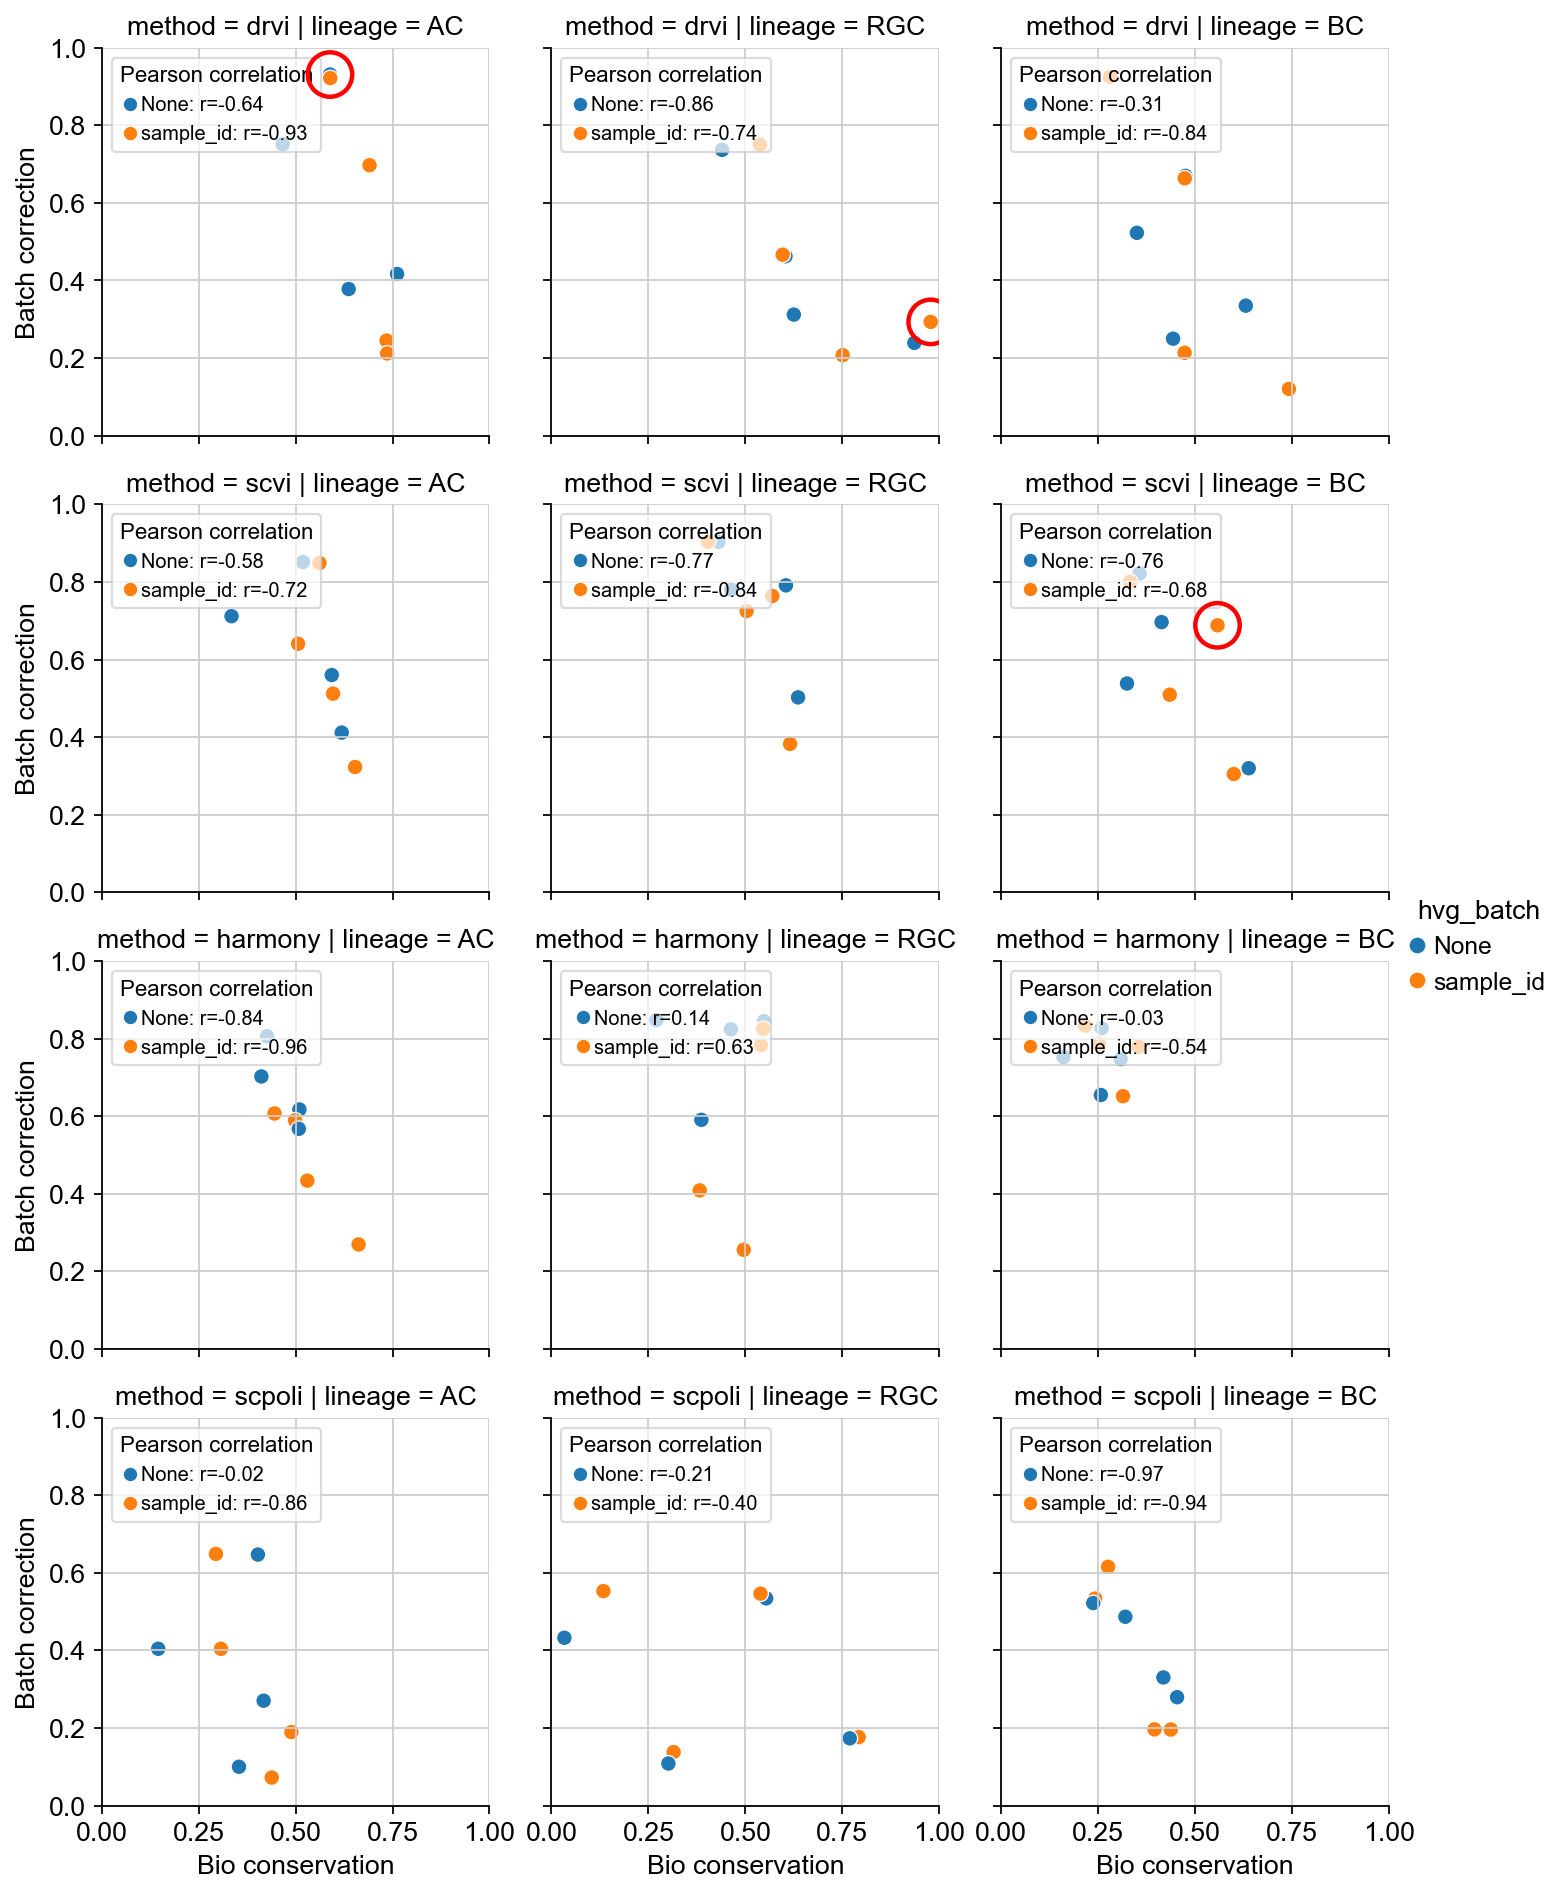

In [23]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='hvg_batch',
    col='lineage',
    row='method',
    palette='tab10',
    height=3,
    s=50,
    highlight_query='is_max_in_lineage',
)

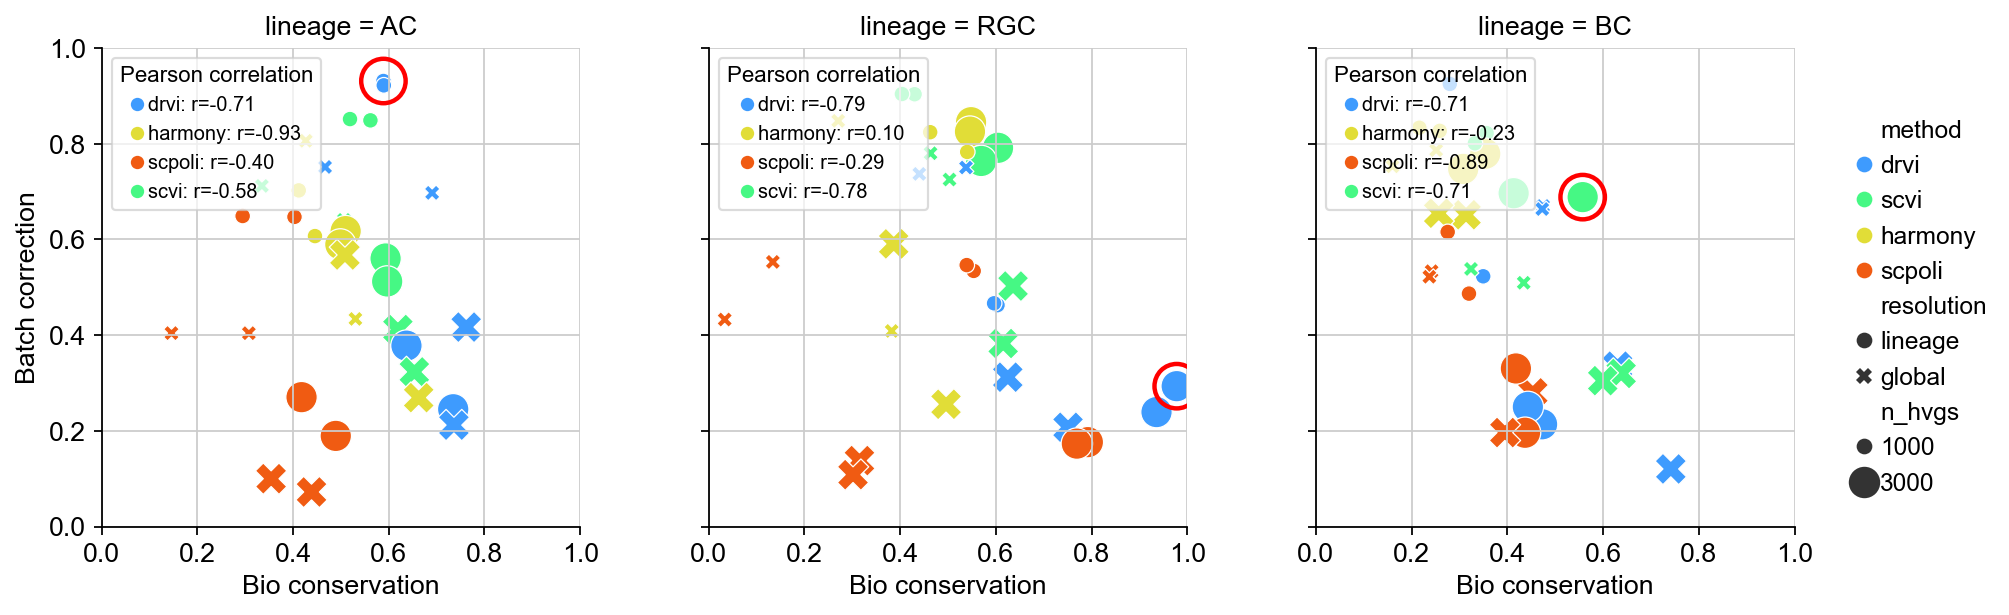

In [24]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='method',
    style='resolution',
    size='n_hvgs',
    col='lineage',
    height=4,
    s=50,
    highlight_query='is_max_in_lineage',
)

### Extended Fig 3B-C

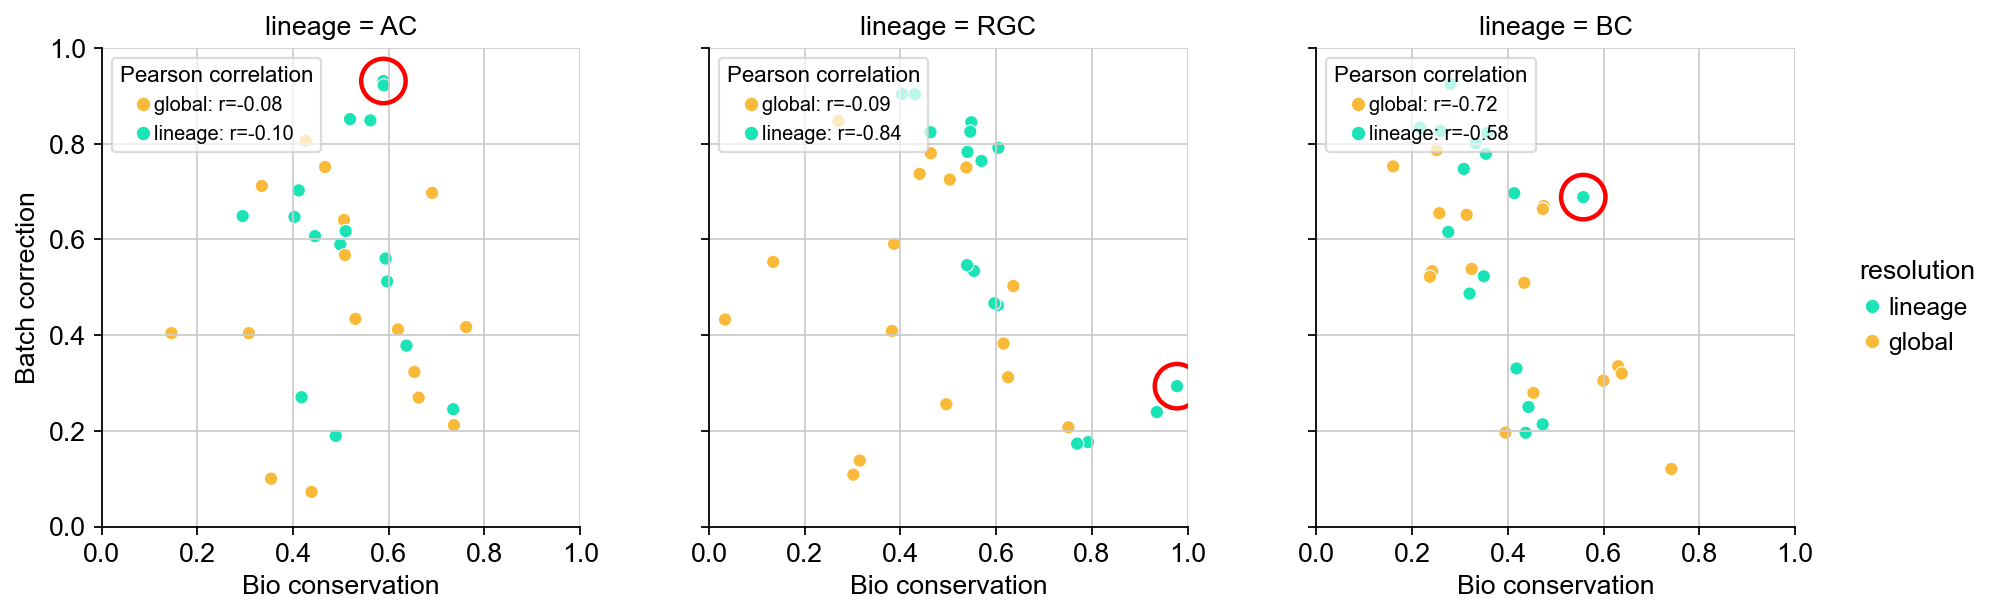

In [25]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    hue='resolution',
    # size='method',
    col='lineage',
    lm_fit=False,
    height=4,
    # s=50,
    save_path=figure_dir / "tradeoff_scatter_lineage_hue=resolution.svg",
    highlight_query='is_max_in_lineage',
)

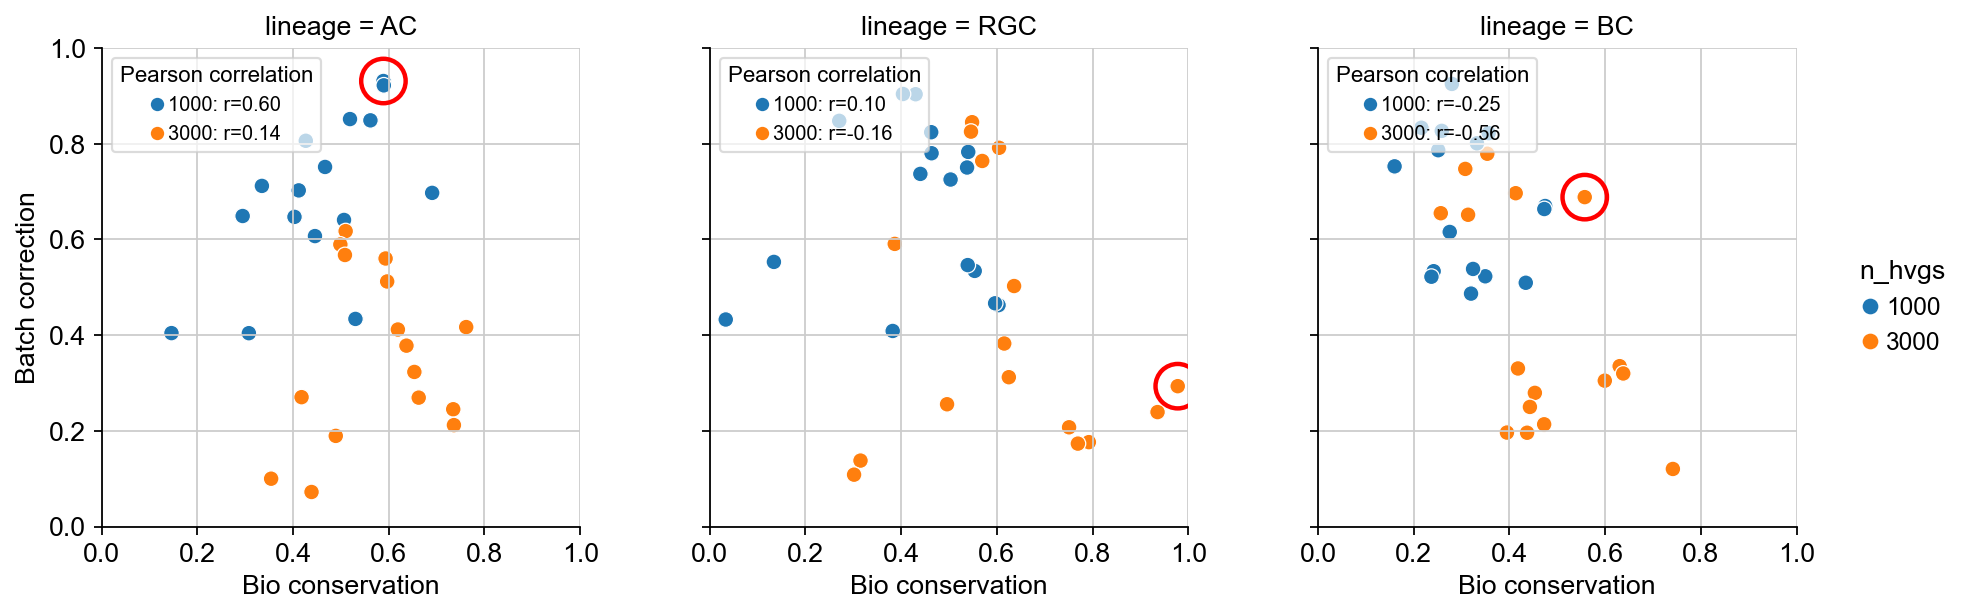

In [26]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    # hue='method',
    hue='n_hvgs',
    col='lineage',
    height=4,
    s=50,
    palette='tab10',
    highlight_query='is_max_in_lineage',
    save_path=figure_dir / "tradeoff_scatter_lineage_hue=n_hvg.svg",
)

## Overall score

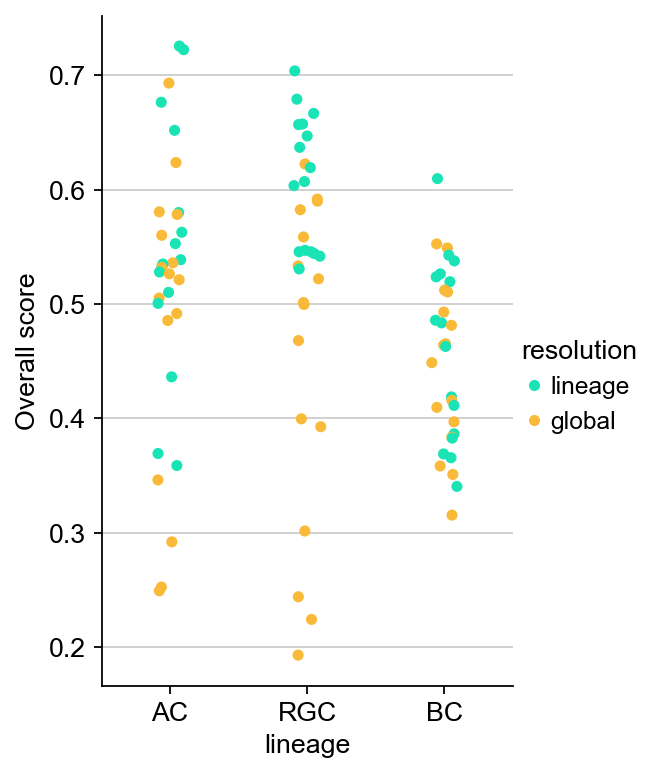

In [27]:
sns.catplot(
    summary,
    y='Overall score',
    x='lineage',
    hue='resolution',
    palette="turbo",
    aspect=0.7,
    # height=3,
)

### Fig 3C

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

RGC_lineage vs. RGC_global: Mann-Whitney-Wilcoxon test two-sided, P_val:4.252e-04 U_stat=2.220e+02
AC_lineage vs. AC_global: Mann-Whitney-Wilcoxon test two-sided, P_val:1.935e-01 U_stat=1.630e+02
BC_lineage vs. BC_global: Mann-Whitney-Wilcoxon test two-sided, P_val:5.847e-01 U_stat=1.430e+02


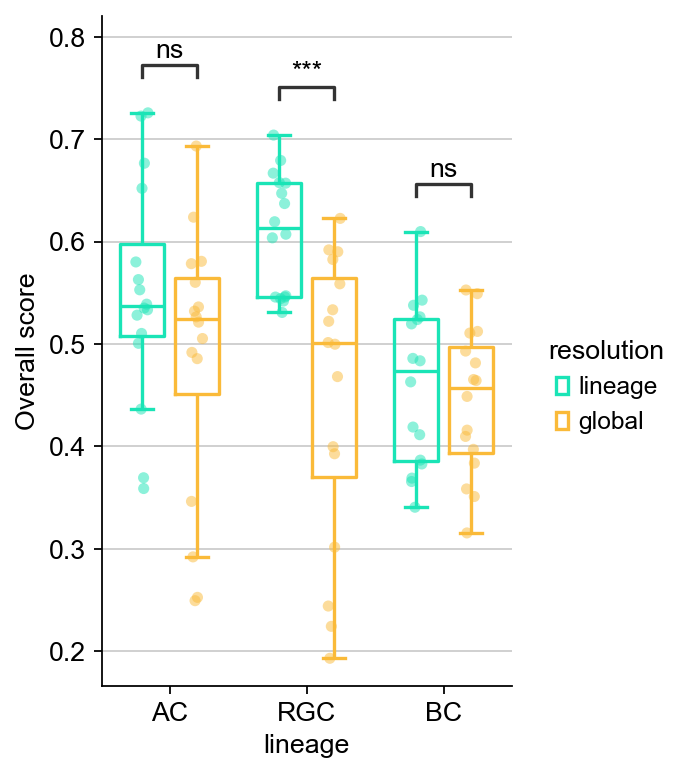

In [28]:
from statannotations.Annotator import Annotator
from itertools import combinations

x = 'lineage'
y = 'Overall score'
hue = 'resolution'

g = sns.catplot(
    summary, y=y, x=x, hue=hue,
    kind='box', fill=False, gap=.2, aspect=0.7,
    palette="turbo", showfliers=False,
)
g.map_dataframe(
    sns.stripplot, y=y, x=x, hue=hue,
    alpha=0.5, dodge=True, palette="turbo",
)

# Build within-lineage pairs: compare every resolution vs every other, per lineage
lineages = summary[x].unique()
resolutions = summary[hue].unique()
pairs = [
    ((lin, r1), (lin, r2))
    for lin in lineages
    for r1, r2 in combinations(resolutions, 2)
]

ax = g.ax  # single facet → one axis
annotator = Annotator(
    ax, pairs, data=summary, x=x, y=y, hue=hue,
)
annotator.configure(
    test="Mann-Whitney",       # Mann-Whitney U
    text_format="star",         # or "simple" for p-values
    loc="inside",
    comparisons_correction=None,  # e.g. "Benjamini-Hochberg" if you want FDR
)
annotator.apply_and_annotate()

g.savefig(figure_dir / "global_vs_lineage_boxplot.svg", format="svg", bbox_inches="tight")

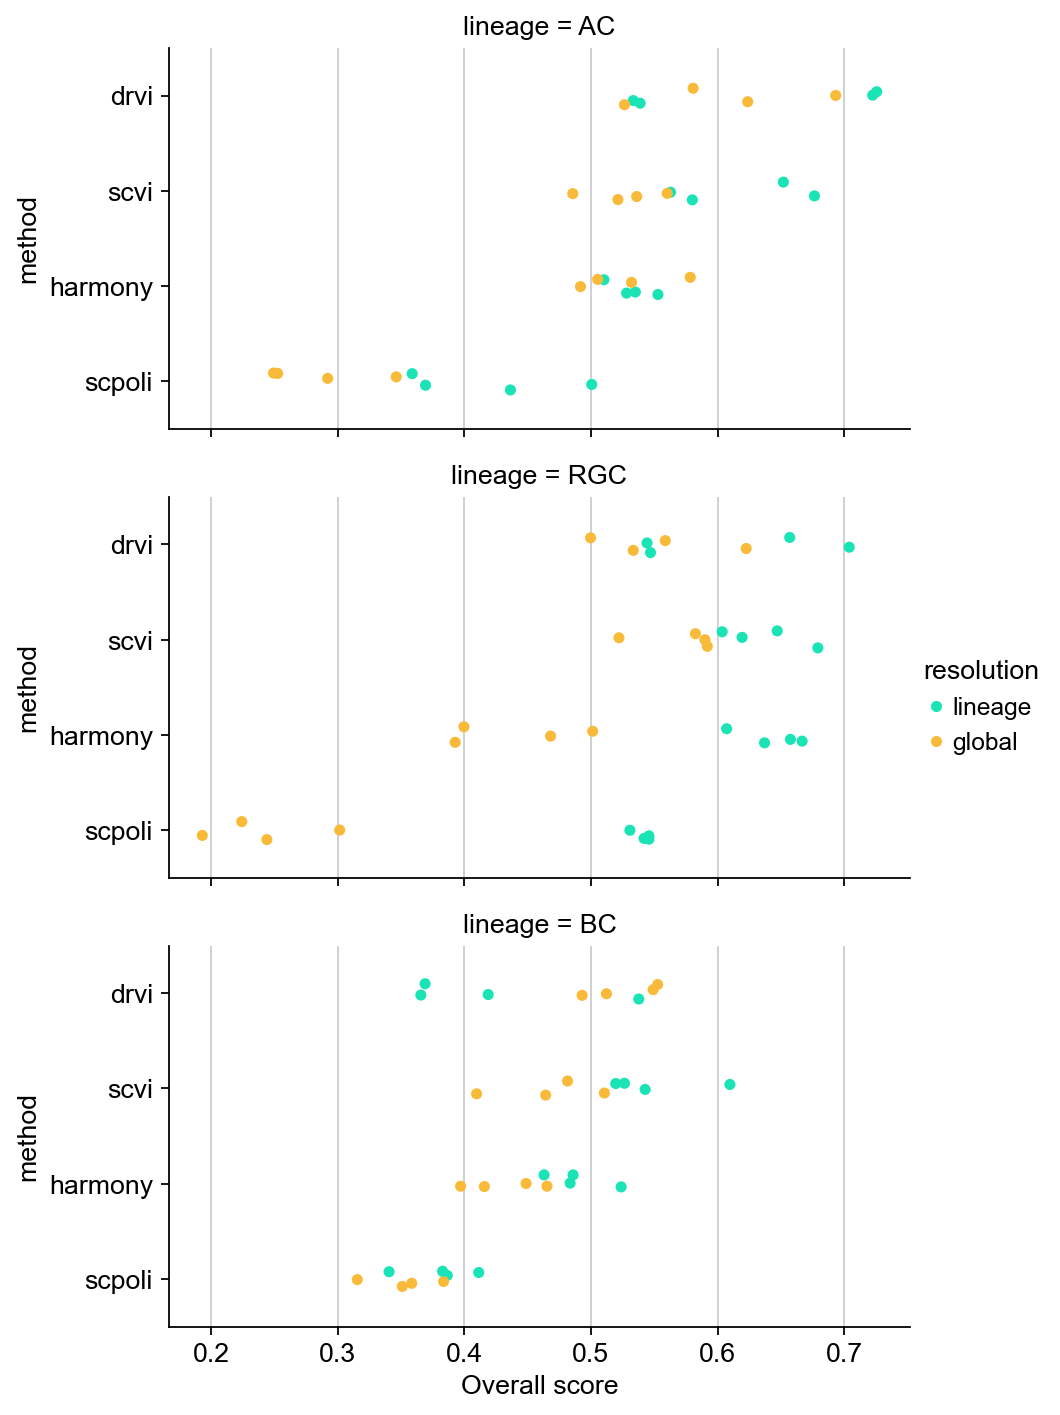

In [29]:
sns.catplot(
    summary,
    x='Overall score',
    y='method',
    hue='resolution',
    row='lineage',
    palette="turbo",
    aspect=2,
    height=3,
)

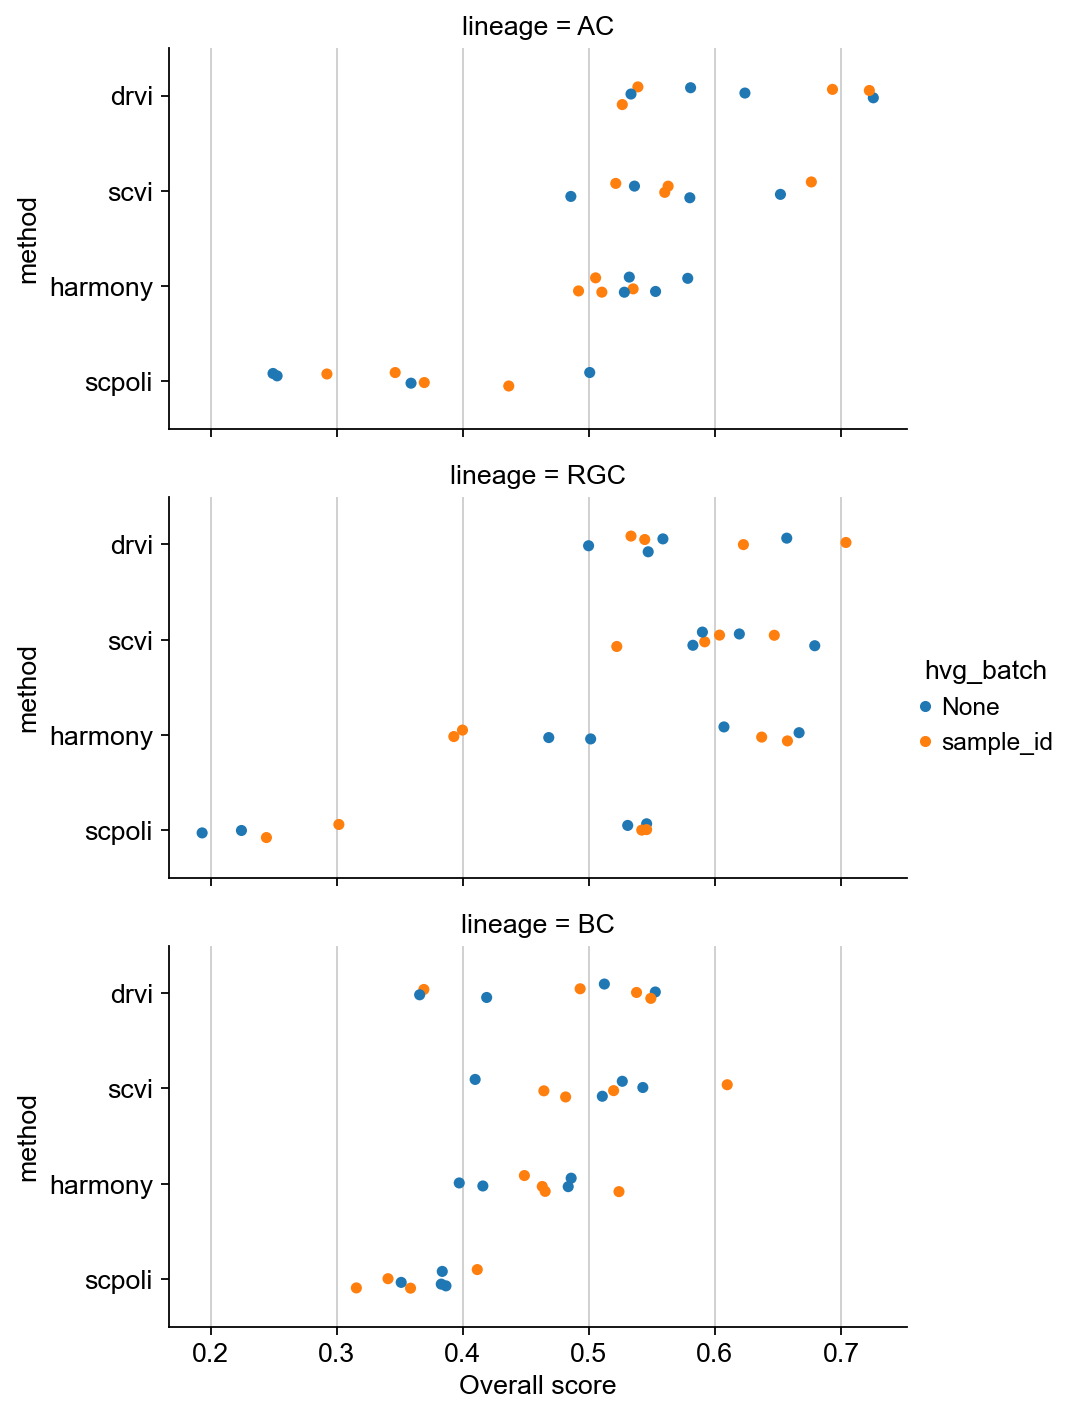

In [30]:
sns.catplot(
    summary,
    x='Overall score',
    y='method',
    hue='hvg_batch',
    row='lineage',
    aspect=2,
    height=3,
)

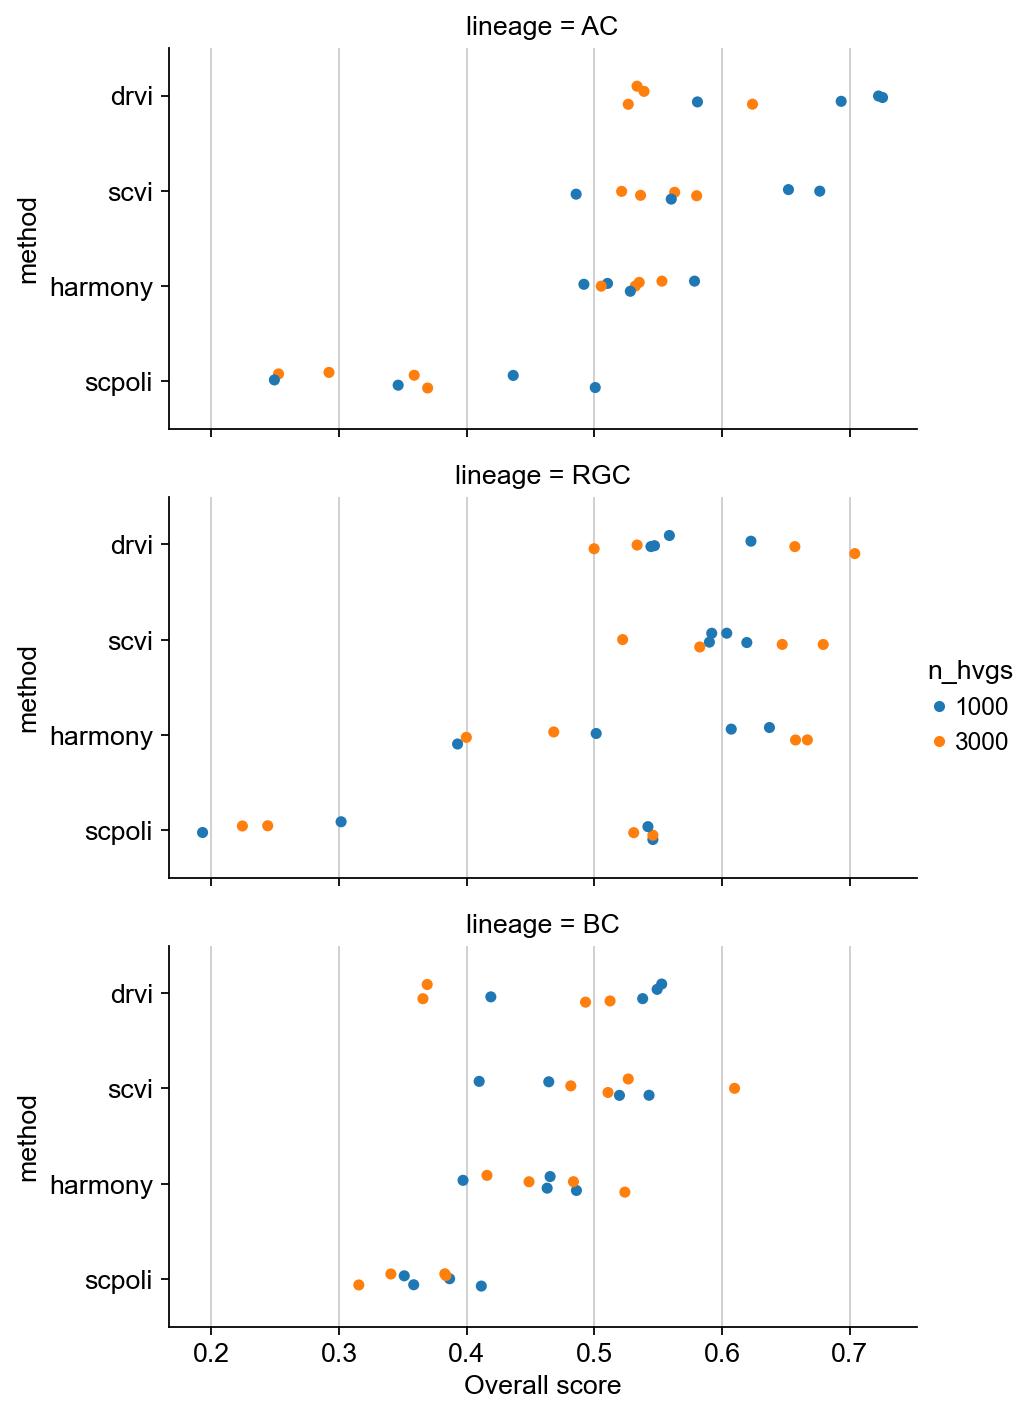

In [31]:
sns.catplot(
    summary,
    x='Overall score',
    y='method',
    hue='n_hvgs',
    row='lineage',
    aspect=2,
    height=3,
    palette='tab10',
)